In [4]:
import pandas as pd

df = pd.read_csv("Dataset.csv")

print("Columns in dataset:", df.columns)


Columns in dataset: Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')


In [5]:
# Replace NaN with empty string
df['Cuisines'] = df['Cuisines'].fillna('')

# Split cuisines into lists
df['Cuisine List'] = df['Cuisines'].apply(lambda x: [c.strip() for c in x.split(',') if c.strip() != ''])


In [6]:
from collections import Counter

# Convert cuisine lists into tuples for counting
cuisine_combos = df['Cuisine List'].apply(lambda x: tuple(sorted(x)) if x else None)

# Drop empty combos
cuisine_combos = cuisine_combos.dropna()

combo_counts = Counter(cuisine_combos)

# Top 10 most common combinations
top_combos = combo_counts.most_common(10)

print("Top Cuisine Combinations:")
for combo, count in top_combos:
    print(f"{combo}: {count} restaurants")


Top Cuisine Combinations:
('North Indian',): 936 restaurants
('Chinese', 'North Indian'): 616 restaurants
('Mughlai', 'North Indian'): 394 restaurants
('Chinese',): 354 restaurants
('Fast Food',): 354 restaurants
('Chinese', 'Mughlai', 'North Indian'): 306 restaurants
('Cafe',): 299 restaurants
('Bakery',): 218 restaurants
('Bakery', 'Desserts'): 181 restaurants
('Chinese', 'Fast Food'): 159 restaurants


In [7]:
# Add cuisine combination column
df['Cuisine Combo'] = df['Cuisine List'].apply(lambda x: ', '.join(sorted(x)) if x else None)

# Group by cuisine combo and calculate average rating
combo_ratings = df.groupby('Cuisine Combo')['Aggregate rating'].mean().sort_values(ascending=False)

print("\nAverage Ratings by Cuisine Combination:")
print(combo_ratings.head(10))



Average Ratings by Cuisine Combination:
Cuisine Combo
World Cuisine                      4.9
American, BBQ, Sandwich            4.9
American, Healthy Food, Mexican    4.9
American, Coffee and Tea           4.9
American, Caribbean, Seafood       4.9
Contemporary, European             4.9
European, German                   4.9
American, Sandwich, Tea            4.9
Bar Food, Burger, Steak            4.9
BBQ, Breakfast, Southern           4.9
Name: Aggregate rating, dtype: float64


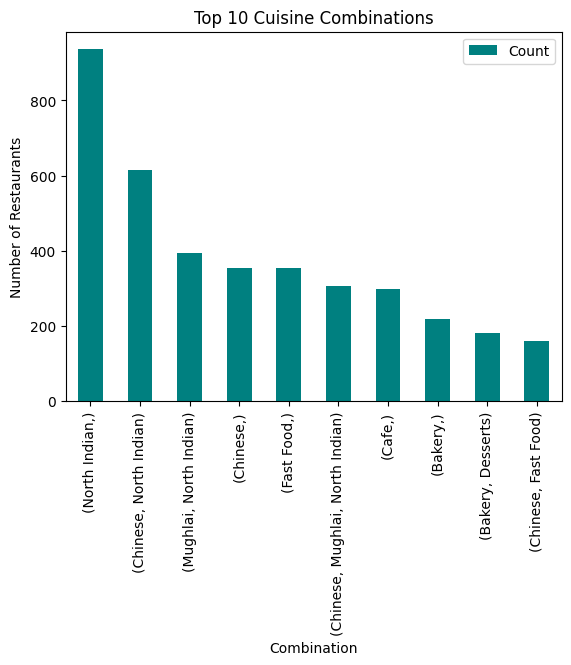

In [8]:
import matplotlib.pyplot as plt

pd.DataFrame(top_combos, columns=['Combination','Count']).set_index('Combination').plot(kind='bar', color='teal')
plt.title("Top 10 Cuisine Combinations")
plt.ylabel("Number of Restaurants")
plt.show()
